In [1]:
# Required imports

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

In [2]:
import random
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"All random seeds fixed to {SEED} for full reproducibility.")

All random seeds fixed to 42 for full reproducibility.


In [3]:
# Download stock data

ticker = "AAPL"
start_date = "2010-01-01"
end_date = "2026-02-25"

data = yf.download(ticker, start=start_date, end=end_date, progress=False)
df = data.reset_index()[["Date", "Close"]]
df['Date'] = pd.to_datetime(df['Date'])
df.index = df.pop('Date')

df

Price,Close
Ticker,AAPL
Date,
2010-01-04,6.412382
2010-01-05,6.423470
2010-01-06,6.321295
2010-01-07,6.309610
2010-01-08,6.351558
...,...
2026-02-18,264.350006
2026-02-19,260.579987


In [4]:
df.to_csv("AAPL_closing_prices.csv")
print("Dataset saved to AAPL_closing_prices.csv")
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print("No SQL/NoSQL database required — yfinance returns data directly as a pandas DataFrame.")
print("No JSON or XML parsing was necessary for this dataset.")

Dataset saved to AAPL_closing_prices.csv
Shape: (4060, 1)
Date range: 2010-01-04 00:00:00 to 2026-02-24 00:00:00
No SQL/NoSQL database required — yfinance returns data directly as a pandas DataFrame.
No JSON or XML parsing was necessary for this dataset.


In [5]:
# Check missing values

print("Missing values:\n", df.isnull().sum())

Missing values:
 Price  Ticker
Close  AAPL      0
dtype: int64


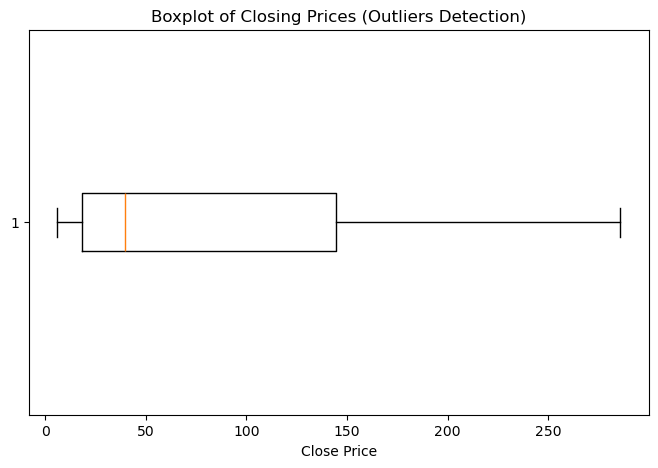

In [6]:
# Checking Outliers

plt.figure(figsize=(8, 5))
plt.boxplot(df['Close'], vert=False)
plt.title("Boxplot of Closing Prices (Outliers Detection)")
plt.xlabel("Close Price")
plt.show()

In [7]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nSummary Statistics:\n", df.describe())

Shape: (4060, 1)

Data Types:
 Price  Ticker
Close  AAPL      float64
dtype: object

Summary Statistics:
 Price         Close
Ticker         AAPL
count   4060.000000
mean      79.079240
std       76.621780
min        5.754396
25%       18.348833
50%       39.535433
75%      144.310432
max      285.922455


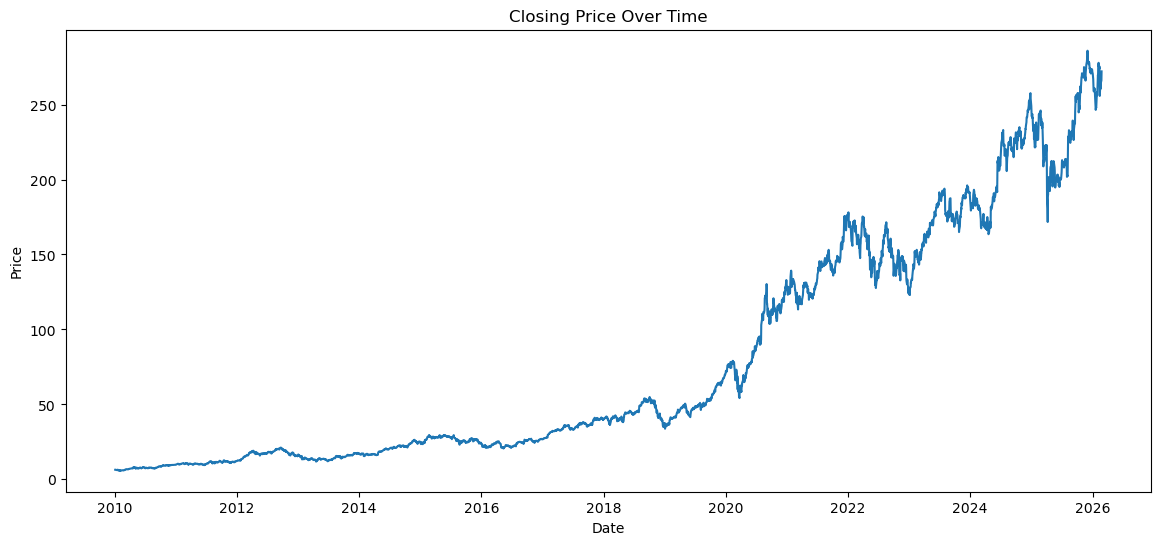

In [8]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Close'])
plt.title("Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

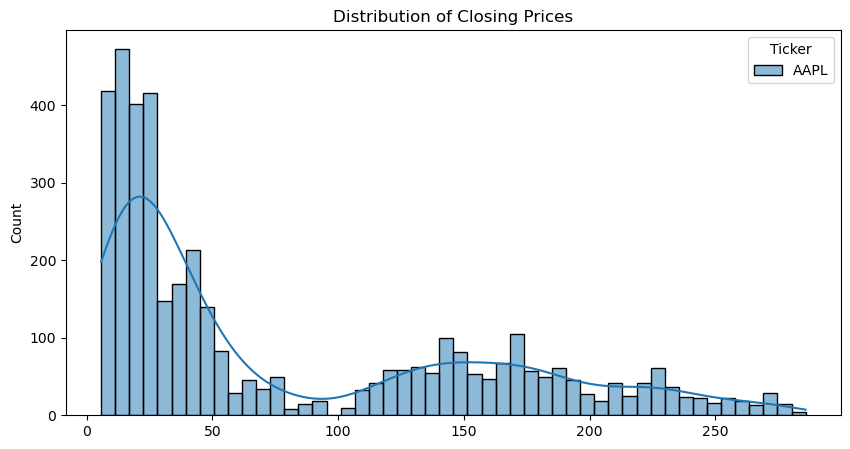

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(df['Close'], bins=50, kde=True)
plt.title("Distribution of Closing Prices")
plt.show()

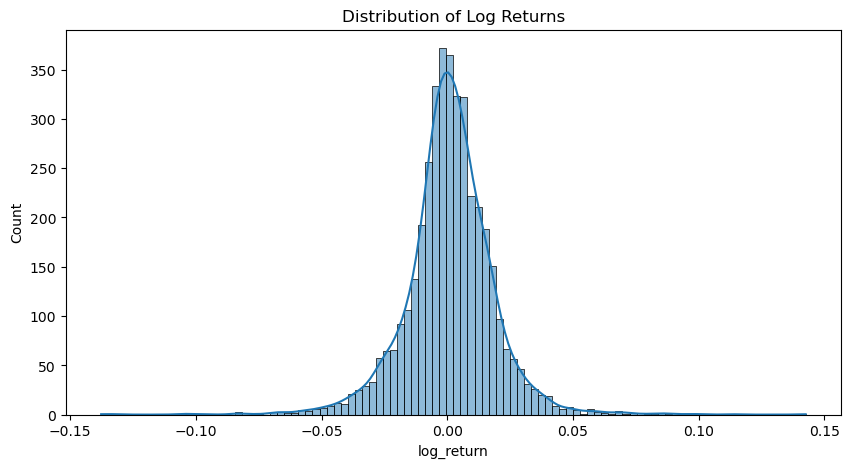

In [10]:
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df = df.dropna()

plt.figure(figsize=(10,5))
sns.histplot(df['log_return'], bins=100, kde=True)
plt.title("Distribution of Log Returns")
plt.show()


In [11]:
# Formal Augmented Dickey-Fuller (ADF) Stationarity Test
from statsmodels.tsa.stattools import adfuller

# Test on raw Close price
adf_price = adfuller(df['Close'].dropna())
print("=== ADF Test: Raw Close Price ===")
print(f"  ADF Statistic : {adf_price[0]:.4f}")
print(f"  p-value       : {adf_price[1]:.4f}")
print(f"  Conclusion    : {'Non-stationary (fail to reject H0)' if adf_price[1] > 0.05 else 'Stationary (reject H0)'}")

# Test on log returns
adf_returns = adfuller(df['log_return'].dropna())
print("\n=== ADF Test: Log Returns ===")
print(f"  ADF Statistic : {adf_returns[0]:.4f}")
print(f"  p-value       : {adf_returns[1]:.4f}")
print(f"  Conclusion    : {'Non-stationary (fail to reject H0)' if adf_returns[1] > 0.05 else 'Stationary (reject H0)'}")

=== ADF Test: Raw Close Price ===
  ADF Statistic : 1.2059
  p-value       : 0.9960
  Conclusion    : Non-stationary (fail to reject H0)

=== ADF Test: Log Returns ===
  ADF Statistic : -21.5494
  p-value       : 0.0000
  Conclusion    : Stationary (reject H0)


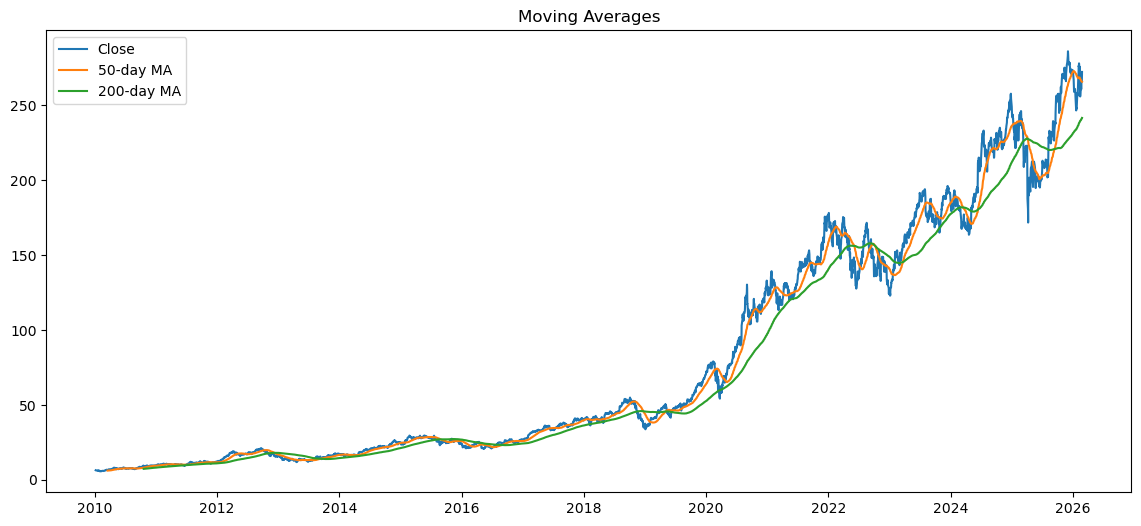

In [12]:
df = df.copy()

df['MA_50'] = df['Close'].rolling(50).mean()
df['MA_200'] = df['Close'].rolling(200).mean()

plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close')
plt.plot(df['MA_50'], label='50-day MA')
plt.plot(df['MA_200'], label='200-day MA')
plt.legend()
plt.title("Moving Averages")
plt.show()


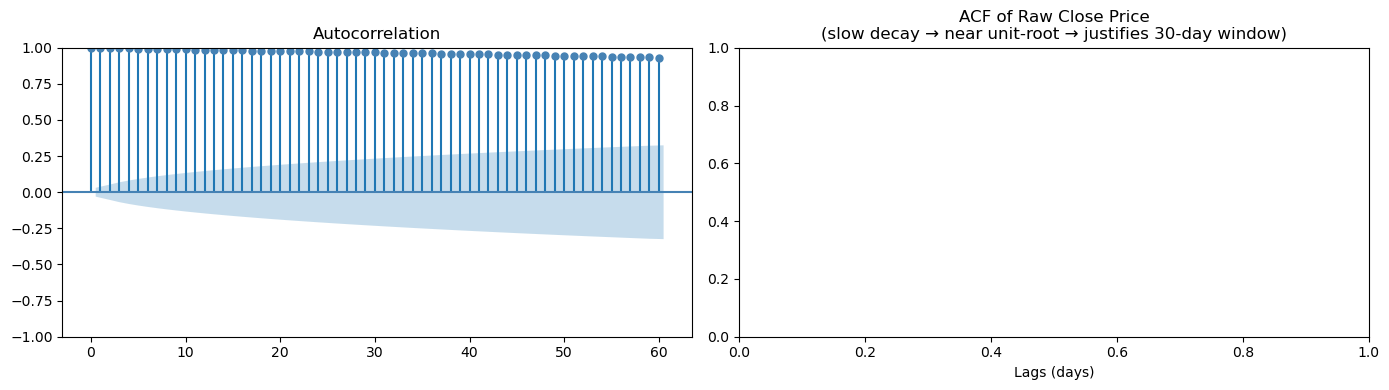

In [13]:
# ACF Plot — justifies 30-day look-back window
from statsmodels.graphics.tsaplots import plot_acf
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ACF of raw Close price
plot_acf(df['Close'].dropna(), lags=60, ax=axes[0], color='steelblue')
plt.title("ACF of Raw Close Price\n(slow decay → near unit-root → justifies 30-day window)")
plt.xlabel("Lags (days)")
plt.tight_layout()
plt.show()

In [14]:
# Create sliding windows

def df_to_windowed_np(df, n=30):
    close_values = df['Close'].to_numpy().flatten()
    X = np.lib.stride_tricks.sliding_window_view(close_values, window_shape=n+1)
    X_values = X[:, :-1]
    Y_values = X[:, -1]
    dates = df.index[n:]
    return dates, X_values, Y_values

sequence_length = 30
dates, X, y = df_to_windowed_np(df, n=sequence_length)

X.shape, y.shape

((4029, 30), (4029,))

In [15]:
# # Scale data

# scaler_X = MinMaxScaler()
# scaler_y = MinMaxScaler()

# X_scaled = scaler_X.fit_transform(X.reshape(-1,1)).reshape(X.shape)
# y_scaled = scaler_y.fit_transform(y.reshape(-1,1)).flatten()

# # Add feature dimension for LSTM
# X_scaled = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))
# X_scaled.shape

In [16]:
# # Split into train/val/test

# q_80 = int(len(dates) * 0.8)
# q_90 = int(len(dates) * 0.9)

# X_train, y_train = X_scaled[:q_80], y_scaled[:q_80]
# X_val, y_val     = X_scaled[q_80:q_90], y_scaled[q_80:q_90]
# X_test, y_test   = X_scaled[q_90:], y_scaled[q_90:]
# dates_train, dates_val, dates_test = dates[:q_80], dates[q_80:q_90], dates[q_90:]

# X_train.shape, X_val.shape, X_test.shape 

# CORRECTED — fit scaler only on training data
q_80 = int(len(dates) * 0.8)
q_90 = int(len(dates) * 0.9)

# Split raw (unscaled) first
X_train_raw = X[:q_80]
X_val_raw   = X[q_80:q_90]
X_test_raw  = X[q_90:]
y_train_raw = y[:q_80]
y_val_raw   = y[q_80:q_90]
y_test_raw  = y[q_90:]

# Fit scalers ONLY on training data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_2d = scaler_X.fit_transform(X_train_raw.reshape(-1,1)).reshape(X_train_raw.shape)
X_val_2d   = scaler_X.transform(X_val_raw.reshape(-1,1)).reshape(X_val_raw.shape)
X_test_2d  = scaler_X.transform(X_test_raw.reshape(-1,1)).reshape(X_test_raw.shape)

y_train = scaler_y.fit_transform(y_train_raw.reshape(-1,1)).flatten()
y_val   = scaler_y.transform(y_val_raw.reshape(-1,1)).flatten()
y_test  = scaler_y.transform(y_test_raw.reshape(-1,1)).flatten()

# Reshape for LSTM
X_train = X_train_2d.reshape((X_train_2d.shape[0], X_train_2d.shape[1], 1))
X_val   = X_val_2d.reshape((X_val_2d.shape[0], X_val_2d.shape[1], 1))
X_test  = X_test_2d.reshape((X_test_2d.shape[0], X_test_2d.shape[1], 1))

dates_train = dates[:q_80]
dates_val   = dates[q_80:q_90]
dates_test  = dates[q_90:]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (3223, 30, 1), Val: (403, 30, 1), Test: (403, 30, 1)


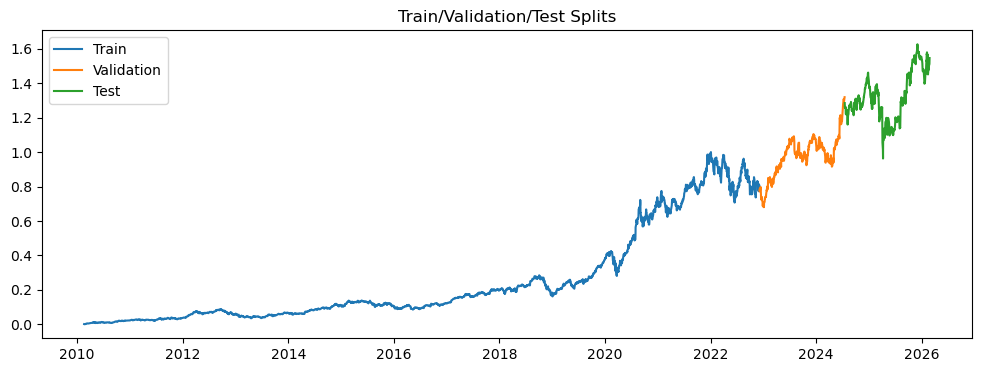

In [17]:
plt.figure(figsize=(12,4))
plt.plot(dates_train, y_train, label='Train')
plt.plot(dates_val, y_val, label='Validation')
plt.plot(dates_test, y_test, label='Test')
plt.legend()
plt.title("Train/Validation/Test Splits")
plt.show()

In [18]:
# PyTorch tensors and GPU setup

device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train, dtype=torch.float32, device=device).unsqueeze(1)
X_val_t   = torch.tensor(X_val, dtype=torch.float32, device=device)
y_val_t   = torch.tensor(y_val, dtype=torch.float32, device=device).unsqueeze(1)
X_test_t  = torch.tensor(X_test, dtype=torch.float32, device=device)
y_test_t  = torch.tensor(y_test, dtype=torch.float32, device=device).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64)

Using device: mps


In [19]:
# Define LSTM model

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, dense_size=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, dense_size)
        self.fc2 = nn.Linear(dense_size, dense_size)
        self.fc3 = nn.Linear(dense_size, 1)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # Last timestep
        out = torch.relu(self.fc1(out))
        out = torch.relu(self.fc2(out))
        out = self.fc3(out)
        return out

model = LSTMModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [20]:
epochs = 50
train_losses = []
val_losses = []

for epoch in range(1, epochs+1):
    # Training
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch 1/50 - Train Loss: 0.0840, Val Loss: 0.6607
Epoch 2/50 - Train Loss: 0.0761, Val Loss: 0.5847
Epoch 3/50 - Train Loss: 0.0678, Val Loss: 0.4235
Epoch 4/50 - Train Loss: 0.0308, Val Loss: 0.0208
Epoch 5/50 - Train Loss: 0.0066, Val Loss: 0.0311
Epoch 6/50 - Train Loss: 0.0045, Val Loss: 0.0395
Epoch 7/50 - Train Loss: 0.0035, Val Loss: 0.0420
Epoch 8/50 - Train Loss: 0.0028, Val Loss: 0.0343
Epoch 9/50 - Train Loss: 0.0022, Val Loss: 0.0300
Epoch 10/50 - Train Loss: 0.0018, Val Loss: 0.0268
Epoch 11/50 - Train Loss: 0.0015, Val Loss: 0.0227
Epoch 12/50 - Train Loss: 0.0012, Val Loss: 0.0211
Epoch 13/50 - Train Loss: 0.0010, Val Loss: 0.0165
Epoch 14/50 - Train Loss: 0.0009, Val Loss: 0.0138
Epoch 15/50 - Train Loss: 0.0008, Val Loss: 0.0162
Epoch 16/50 - Train Loss: 0.0007, Val Loss: 0.0119
Epoch 17/50 - Train Loss: 0.0006, Val Loss: 0.0112
Epoch 18/50 - Train Loss: 0.0006, Val Loss: 0.0114
Epoch 19/50 - Train Loss: 0.0006, Val Loss: 0.0106
Epoch 20/50 - Train Loss: 0.0005, Val Lo

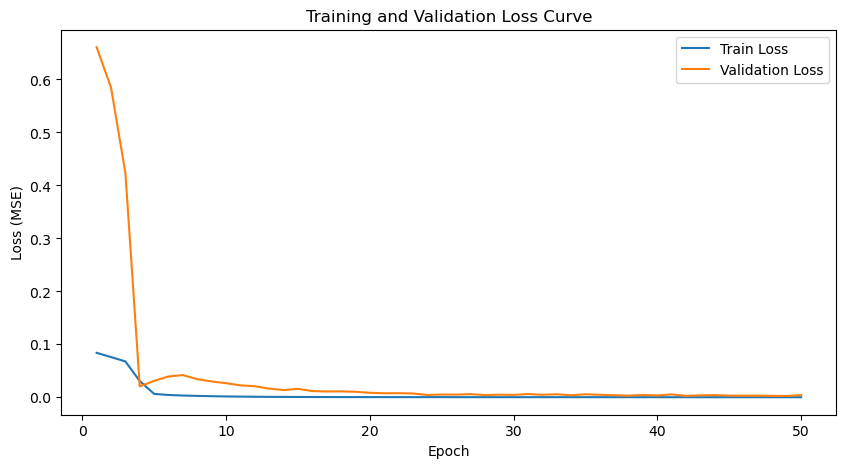

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training and Validation Loss Curve")
plt.legend()
plt.show()

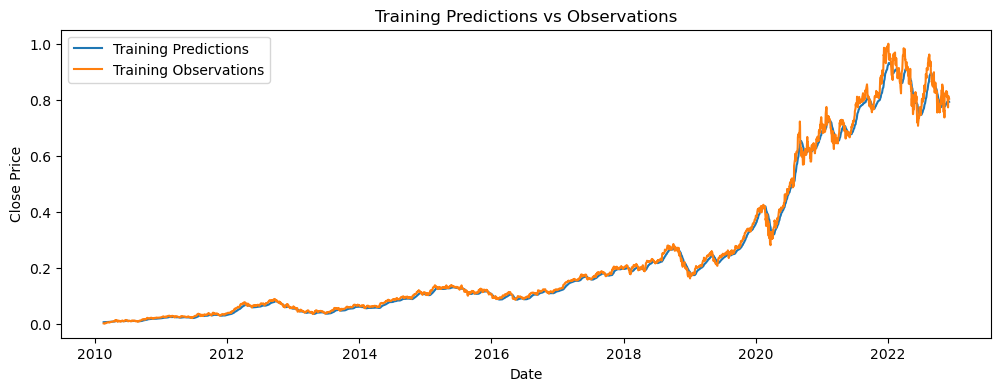

In [22]:
model.eval()

with torch.no_grad():
    train_preds = model(torch.tensor(X_train, dtype=torch.float32, device=device))
    train_preds = train_preds.cpu().numpy().flatten() 

plt.figure(figsize=(12, 4))
plt.plot(dates_train, train_preds, label='Training Predictions')
plt.plot(dates_train, y_train, label='Training Observations')
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Training Predictions vs Observations")
plt.legend()
plt.show()


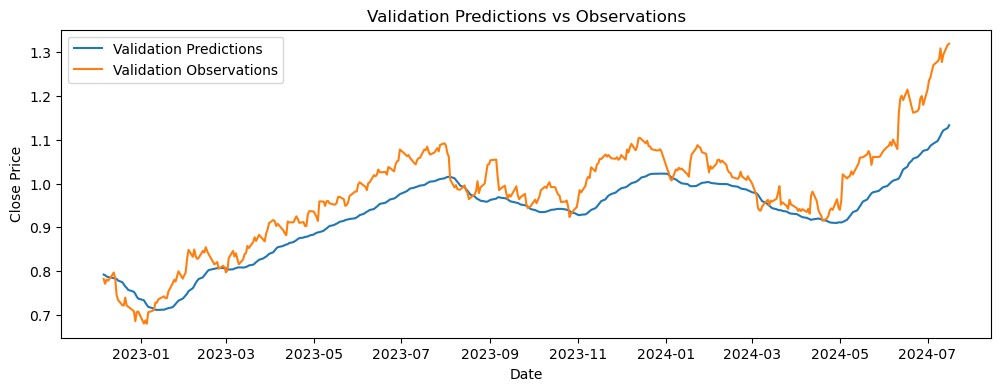

In [23]:
model.eval()

with torch.no_grad():
    val_preds = model(torch.tensor(X_val, dtype=torch.float32, device=device))
    val_preds = val_preds.cpu().numpy().flatten() 

plt.figure(figsize=(12, 4))
plt.plot(dates_val, val_preds, label='Validation Predictions')
plt.plot(dates_val, y_val, label='Validation Observations')
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Validation Predictions vs Observations")
plt.legend()
plt.show()


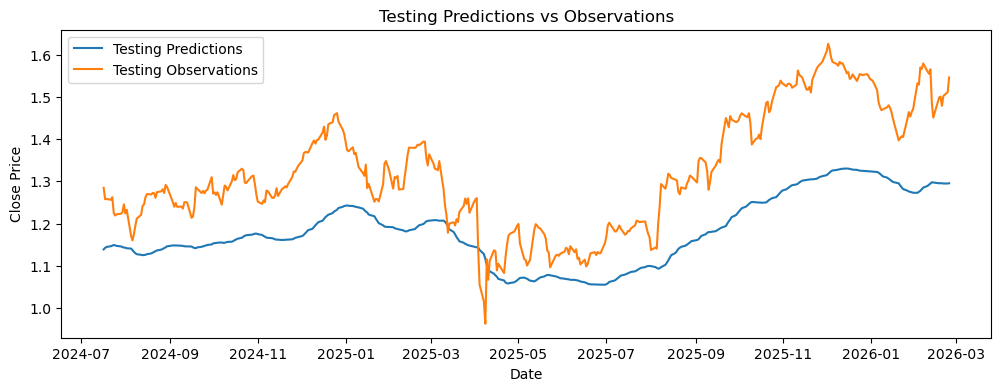

In [24]:
model.eval()

with torch.no_grad():
    test_preds = model(torch.tensor(X_test, dtype=torch.float32, device=device))
    test_preds = test_preds.cpu().numpy().flatten()

plt.figure(figsize=(12, 4))
plt.plot(dates_test, test_preds, label='Testing Predictions')
plt.plot(dates_test, y_test, label='Testing Observations')
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Testing Predictions vs Observations")
plt.legend()
plt.show()


In [25]:
model.eval()

with torch.no_grad():
    train_preds_t = model(X_train_t)
    val_preds_t   = model(X_val_t)
    test_preds_t  = model(X_test_t)

    mse_loss = nn.MSELoss()(test_preds_t, y_test_t).item()
    mae_loss = nn.L1Loss()(test_preds_t, y_test_t).item()

train_preds = train_preds_t.cpu().numpy()
val_preds   = val_preds_t.cpu().numpy()
test_preds  = test_preds_t.cpu().numpy()

train_preds = scaler_y.inverse_transform(train_preds)
val_preds   = scaler_y.inverse_transform(val_preds)
test_preds  = scaler_y.inverse_transform(test_preds)

y_train_inv = scaler_y.inverse_transform(y_train.reshape(-1,1))
y_val_inv   = scaler_y.inverse_transform(y_val.reshape(-1,1))
y_test_inv  = scaler_y.inverse_transform(y_test.reshape(-1,1))

print(f"Test MSE (scaled): {mse_loss:.4f}")
print(f"Test MAE (scaled): {mae_loss:.4f}")

test_mae_price = np.mean(np.abs(test_preds - y_test_inv))
print(f"Test MAE (actual price units): {test_mae_price:.4f}")


Test MSE (scaled): 0.0245
Test MAE (scaled): 0.1420
Test MAE (actual price units): 24.4573


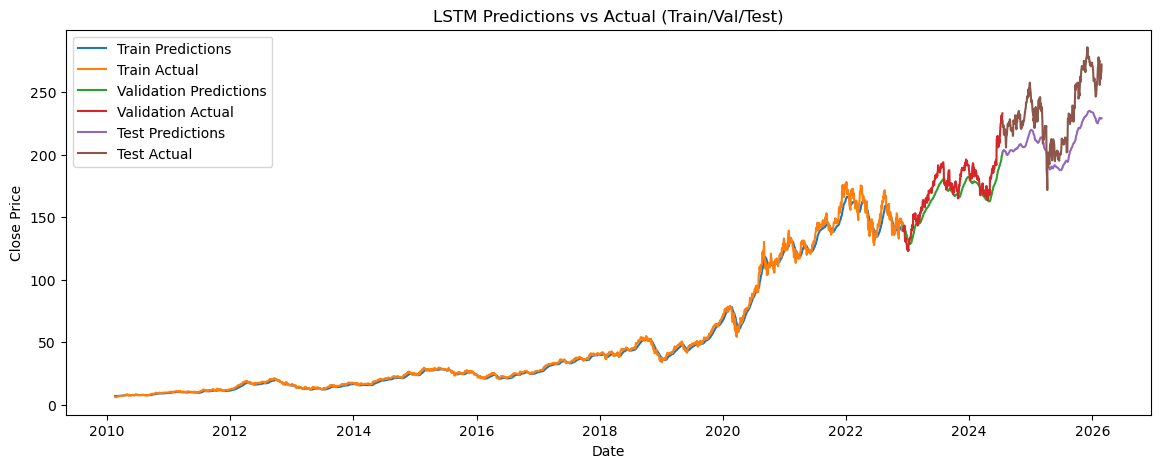

In [26]:
plt.figure(figsize=(14,5))

plt.plot(dates_train, train_preds, label='Train Predictions')
plt.plot(dates_train, y_train_inv, label='Train Actual')

plt.plot(dates_val, val_preds, label='Validation Predictions')
plt.plot(dates_val, y_val_inv, label='Validation Actual')

plt.plot(dates_test, test_preds, label='Test Predictions')
plt.plot(dates_test, y_test_inv, label='Test Actual')

plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("LSTM Predictions vs Actual (Train/Val/Test)")
plt.legend()
plt.show()


# Updated Model

In [27]:
# Updated/Improved LSTM model

class EnhancedLSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=5, dense_size=64, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,
                            batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, dense_size)
        self.fc2 = nn.Linear(dense_size, dense_size)
        self.fc3 = nn.Linear(dense_size, 1)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # Last timestep
        out = self.dropout(out)
        out = torch.relu(self.fc1(out))
        out = torch.relu(self.fc2(out))
        out = self.fc3(out)
        return out

enhanced_model = EnhancedLSTMModel().to(device)
enh_criterion = nn.MSELoss()
enh_optimizer = torch.optim.Adam(enhanced_model.parameters(), lr=0.0005)

In [28]:
epochs = 100
e_train_losses = []
e_val_losses = []

for epoch in range(1, epochs+1):
    # Training
    enhanced_model.train()
    train_loss = 0
    for xb, yb in train_loader:
        enh_optimizer.zero_grad()
        preds = enhanced_model(xb)
        loss = enh_criterion(preds, yb)
        loss.backward()
        enh_optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)
    e_train_losses.append(train_loss)
    
    # Validation
    enhanced_model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = enhanced_model(xb)
            loss = enh_criterion(preds, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    e_val_losses.append(val_loss)
    
    print(f"Epoch {epoch}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch 1/100 - Train Loss: 0.0662, Val Loss: 0.0287
Epoch 2/100 - Train Loss: 0.0080, Val Loss: 0.0626
Epoch 3/100 - Train Loss: 0.0027, Val Loss: 0.0277
Epoch 4/100 - Train Loss: 0.0015, Val Loss: 0.0300
Epoch 5/100 - Train Loss: 0.0016, Val Loss: 0.0193
Epoch 6/100 - Train Loss: 0.0011, Val Loss: 0.0188
Epoch 7/100 - Train Loss: 0.0013, Val Loss: 0.0337
Epoch 8/100 - Train Loss: 0.0010, Val Loss: 0.0236
Epoch 9/100 - Train Loss: 0.0009, Val Loss: 0.0124
Epoch 10/100 - Train Loss: 0.0009, Val Loss: 0.0134
Epoch 11/100 - Train Loss: 0.0010, Val Loss: 0.0109
Epoch 12/100 - Train Loss: 0.0009, Val Loss: 0.0108
Epoch 13/100 - Train Loss: 0.0007, Val Loss: 0.0072
Epoch 14/100 - Train Loss: 0.0008, Val Loss: 0.0144
Epoch 15/100 - Train Loss: 0.0010, Val Loss: 0.0078
Epoch 16/100 - Train Loss: 0.0007, Val Loss: 0.0112
Epoch 17/100 - Train Loss: 0.0008, Val Loss: 0.0083
Epoch 18/100 - Train Loss: 0.0006, Val Loss: 0.0057
Epoch 19/100 - Train Loss: 0.0005, Val Loss: 0.0035
Epoch 20/100 - Train 

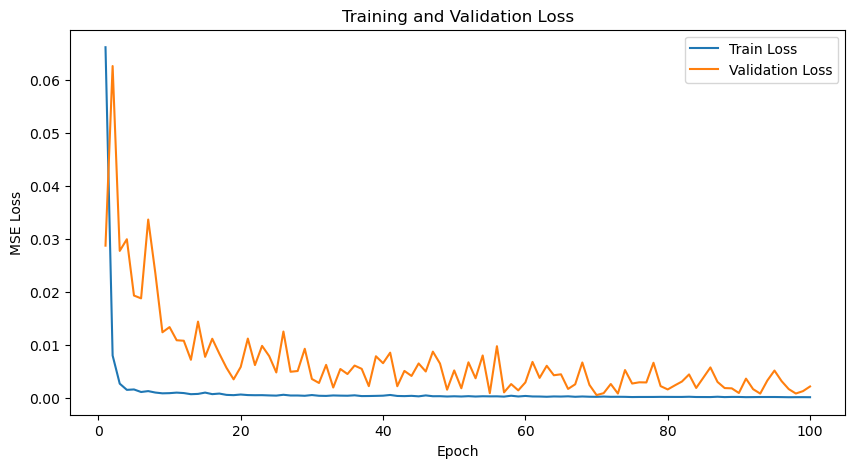

In [29]:
plt.figure(figsize=(10,5))
plt.plot(range(1, epochs+1), e_train_losses, label='Train Loss')
plt.plot(range(1, epochs+1), e_val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

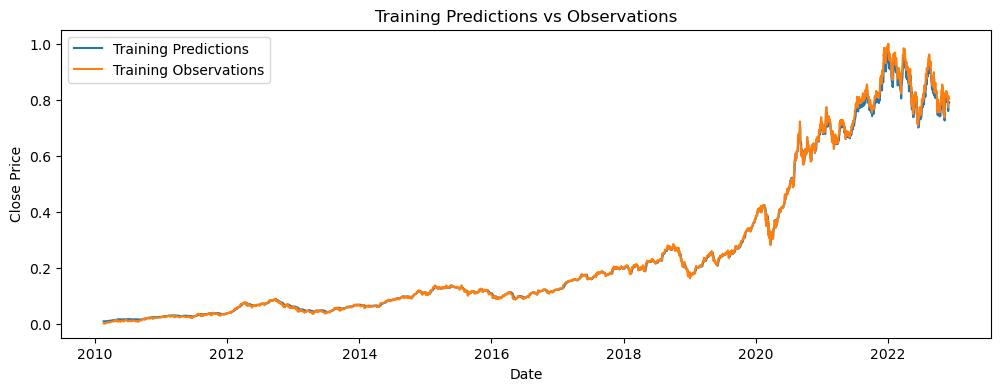

In [30]:
enhanced_model.eval()

with torch.no_grad():
    train_preds = enhanced_model(torch.tensor(X_train, dtype=torch.float32, device=device))
    train_preds = train_preds.cpu().numpy().flatten()  

plt.figure(figsize=(12, 4))
plt.plot(dates_train, train_preds, label='Training Predictions')
plt.plot(dates_train, y_train, label='Training Observations')
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Training Predictions vs Observations")
plt.legend()
plt.show()


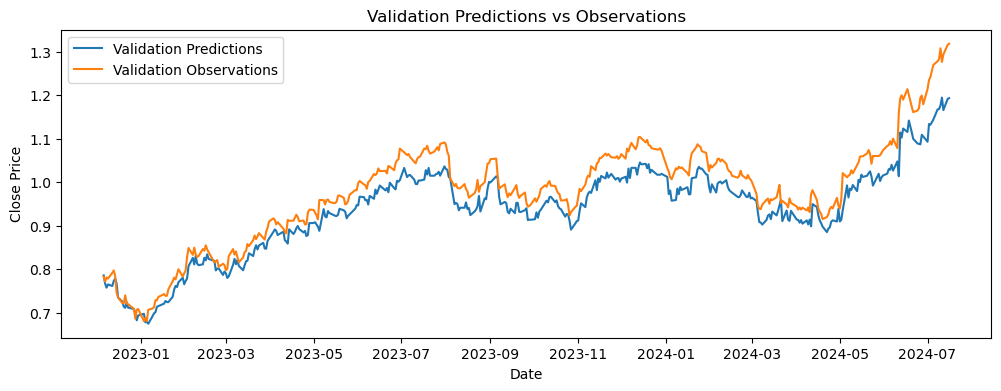

In [31]:
enhanced_model.eval()

with torch.no_grad():
    val_preds = enhanced_model(torch.tensor(X_val, dtype=torch.float32, device=device))
    val_preds = val_preds.cpu().numpy().flatten()  

plt.figure(figsize=(12, 4))
plt.plot(dates_val, val_preds, label='Validation Predictions')
plt.plot(dates_val, y_val, label='Validation Observations')
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Validation Predictions vs Observations")
plt.legend()
plt.show()


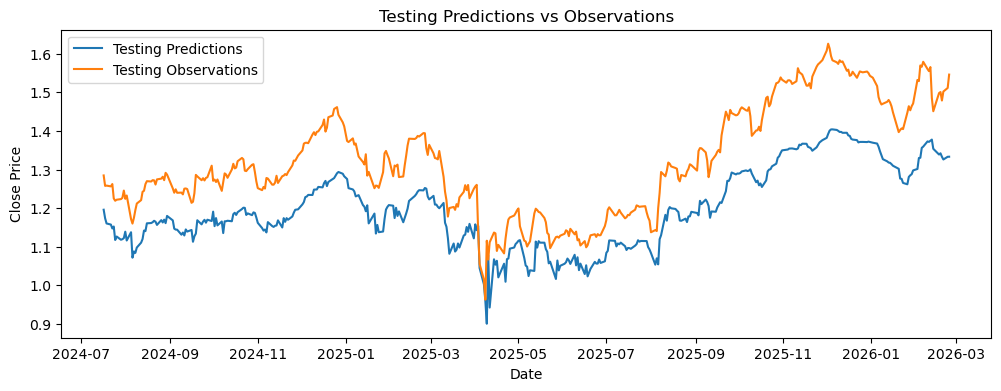

In [32]:
enhanced_model.eval()

with torch.no_grad():
    test_preds = enhanced_model(torch.tensor(X_test, dtype=torch.float32, device=device))
    test_preds = test_preds.cpu().numpy().flatten()

plt.figure(figsize=(12, 4))
plt.plot(dates_test, test_preds, label='Testing Predictions')
plt.plot(dates_test, y_test, label='Testing Observations')
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Testing Predictions vs Observations")
plt.legend()
plt.show()


In [33]:
enhanced_model.eval()
with torch.no_grad():
    train_preds = enhanced_model(X_train_t).cpu().numpy()
    val_preds   = enhanced_model(X_val_t).cpu().numpy()
    test_preds  = enhanced_model(X_test_t).cpu().numpy()

# Inverse transform
train_preds = scaler_y.inverse_transform(train_preds)
y_train_inv = scaler_y.inverse_transform(y_train.reshape(-1,1))
val_preds   = scaler_y.inverse_transform(val_preds)
y_val_inv   = scaler_y.inverse_transform(y_val.reshape(-1,1))
test_preds  = scaler_y.inverse_transform(test_preds)
y_test_inv  = scaler_y.inverse_transform(y_test.reshape(-1,1))

In [34]:
enhanced_model.eval()

with torch.no_grad():
    test_preds = enhanced_model(X_test_t)
    
    mse_loss = nn.MSELoss()(test_preds, y_test_t).item()
    mae_loss = nn.L1Loss()(test_preds, y_test_t).item()
    
    test_preds_inv = scaler_y.inverse_transform(test_preds.cpu().numpy())
    y_test_inv    = scaler_y.inverse_transform(y_test_t.cpu().numpy())

print(f"Test MSE (scaled): {mse_loss:.4f}")
print(f"Test MAE (scaled): {mae_loss:.4f}")

test_mae_price = np.mean(np.abs(test_preds_inv - y_test_inv))
print(f"Test MAE (actual price units): {test_mae_price:.4f}")


Test MSE (scaled): 0.0171
Test MAE (scaled): 0.1237
Test MAE (actual price units): 21.2952


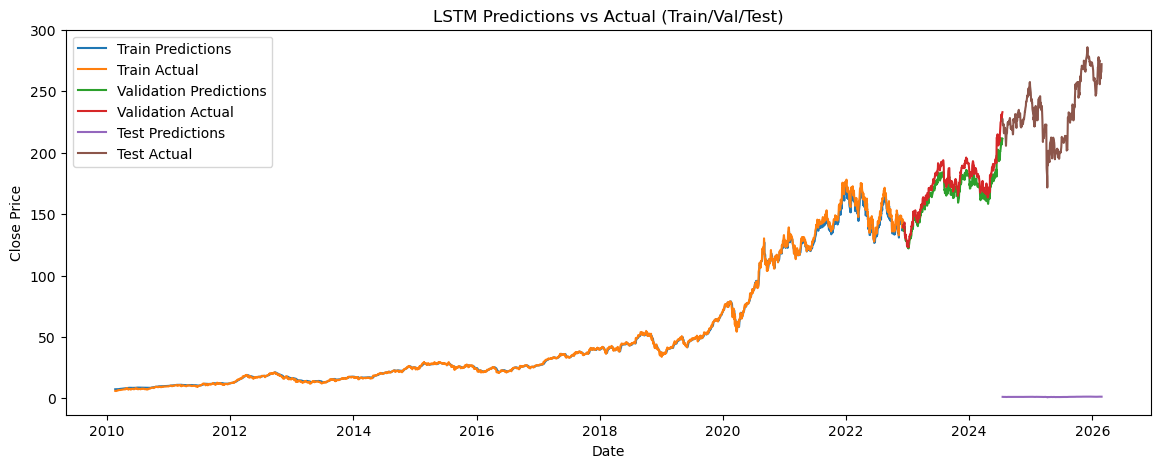

In [35]:
train_preds = train_preds.cpu().numpy() if hasattr(train_preds, 'cpu') else train_preds
y_train_inv = y_train_inv.cpu().numpy() if hasattr(y_train_inv, 'cpu') else y_train_inv
val_preds = val_preds.cpu().numpy() if hasattr(val_preds, 'cpu') else val_preds
y_val_inv = y_val_inv.cpu().numpy() if hasattr(y_val_inv, 'cpu') else y_val_inv
test_preds = test_preds.cpu().numpy() if hasattr(test_preds, 'cpu') else test_preds
y_test_inv = y_test_inv.cpu().numpy() if hasattr(y_test_inv, 'cpu') else y_test_inv

plt.figure(figsize=(14,5))
plt.plot(dates_train, train_preds, label='Train Predictions')
plt.plot(dates_train, y_train_inv, label='Train Actual')
plt.plot(dates_val, val_preds, label='Validation Predictions')
plt.plot(dates_val, y_val_inv, label='Validation Actual')
plt.plot(dates_test, test_preds, label='Test Predictions')
plt.plot(dates_test, y_test_inv, label='Test Actual')
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("LSTM Predictions vs Actual (Train/Val/Test)")
plt.legend()
plt.show()

Baseline — Mean residual: $-24.12, Std: $12.09
Enhanced — Mean residual: $-21.27, Std: $7.40


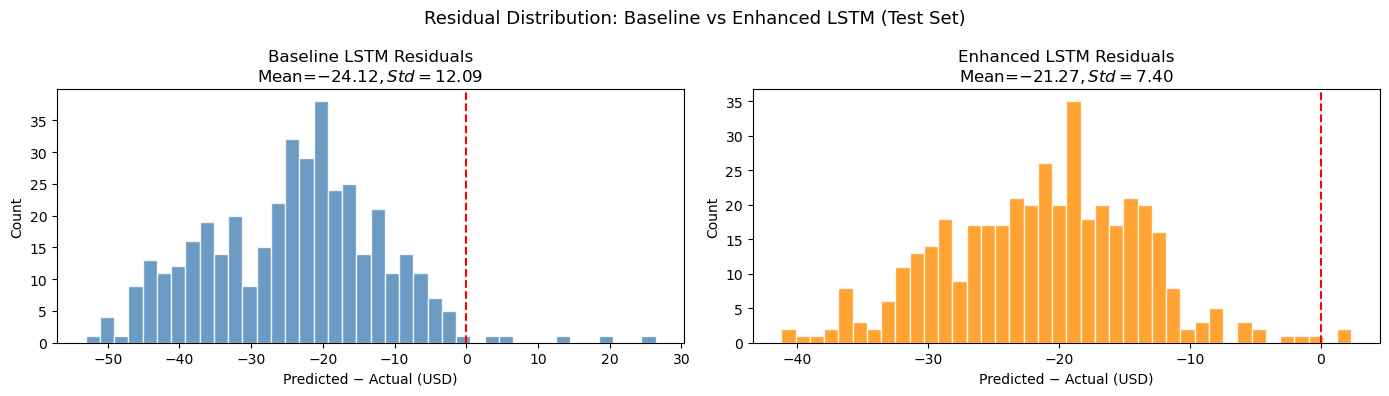

No distributed computing (Spark/HPC) required — dataset ~4,000 rows fits in memory.


In [36]:
# Residual Analysis — recompute both models cleanly from scratch
model.eval()
enhanced_model.eval()

with torch.no_grad():
    # Baseline
    baseline_out = model(X_test_t).cpu().numpy()
    baseline_usd = scaler_y.inverse_transform(baseline_out)
    
    # Enhanced
    enhanced_out = enhanced_model(X_test_t).cpu().numpy()
    enhanced_usd = scaler_y.inverse_transform(enhanced_out)

# True test prices in USD
y_test_usd_plot = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# Residuals: Predicted - Actual
baseline_residuals = (baseline_usd - y_test_usd_plot).flatten()
enhanced_residuals = (enhanced_usd - y_test_usd_plot).flatten()

print(f"Baseline — Mean residual: ${np.mean(baseline_residuals):.2f}, Std: ${np.std(baseline_residuals):.2f}")
print(f"Enhanced — Mean residual: ${np.mean(enhanced_residuals):.2f}, Std: ${np.std(enhanced_residuals):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(baseline_residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title(f"Baseline LSTM Residuals\nMean=${np.mean(baseline_residuals):.2f}, Std=${np.std(baseline_residuals):.2f}")
axes[0].set_xlabel("Predicted − Actual (USD)")
axes[0].set_ylabel("Count")

axes[1].hist(enhanced_residuals, bins=40, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title(f"Enhanced LSTM Residuals\nMean=${np.mean(enhanced_residuals):.2f}, Std=${np.std(enhanced_residuals):.2f}")
axes[1].set_xlabel("Predicted − Actual (USD)")
axes[1].set_ylabel("Count")

plt.suptitle("Residual Distribution: Baseline vs Enhanced LSTM (Test Set)", fontsize=13)
plt.tight_layout()
plt.savefig("residual_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

print("No distributed computing (Spark/HPC) required — dataset ~4,000 rows fits in memory.")

In [37]:
# Count trainable parameters in both models
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

baseline_params  = count_parameters(LSTMModel().to('cpu'))
enhanced_params  = count_parameters(EnhancedLSTMModel().to('cpu'))
ratio            = enhanced_params / baseline_params

print(f"Baseline LSTM   — Trainable parameters: {baseline_params:,}")
print(f"Enhanced LSTM   — Trainable parameters: {enhanced_params:,}")
print(f"Capacity ratio  — Enhanced is {ratio:.1f}× larger than baseline")
print(f"Dropout(0.2) regularizes the {enhanced_params:,}-parameter Enhanced LSTM to prevent overfitting.")

Baseline LSTM   — Trainable parameters: 20,321
Enhanced LSTM   — Trainable parameters: 607,937
Capacity ratio  — Enhanced is 29.9× larger than baseline
Dropout(0.2) regularizes the 607,937-parameter Enhanced LSTM to prevent overfitting.
